# OpenRouter Daily Tokens And Revenue Time Series Validation

Objective:
- Verify whether the aggregate OpenRouter daily `total_tokens` and `estimated_revenue` series show a 7-day weekly seasonality.
- Verify whether both series also exhibit a statistically meaningful upward linear trend.

Success criteria:
- Positive and statistically significant linear trend over the observed window.
- Visible weekday/weekend structure plus meaningful lag-7 autocorrelation after removing the linear trend.


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.3f}'.format

BASE_DIR = Path.cwd()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent
MART_PATH = BASE_DIR / 'data' / 'normalized' / 'marts' / 'daily_provider_economics.parquet'
MART_PATH


PosixPath('/Users/henrywzh/Desktop/Quant/alternative-data/data/normalized/marts/daily_provider_economics.parquet')

In [2]:
mart = pd.read_parquet(MART_PATH)
mart['usage_date'] = pd.to_datetime(mart['usage_date'])

daily = (
    mart.groupby('usage_date', as_index=False)
    .agg(
        total_tokens=('total_tokens', 'sum'),
        estimated_revenue=('estimated_revenue', 'sum'),
    )
    .sort_values('usage_date')
    .reset_index(drop=True)
)

daily['t'] = np.arange(len(daily))
daily['weekday'] = daily['usage_date'].dt.day_name()
daily.head()


,usage_date,total_tokens,estimated_revenue,t,weekday
0,2026-01-16,"1,049,854,770,259.000","994,755.788",0,Friday
1,2026-01-17,"912,508,975,659.000","787,161.133",1,Saturday
2,2026-01-18,"1,004,406,383,104.000","947,132.836",2,Sunday
3,2026-01-19,"1,050,227,766,523.000","1,041,224.241",3,Monday
4,2026-01-20,"1,099,561,585,902.000","1,123,198.891",4,Tuesday


## Aggregate daily series

These plots use the full daily_provider_economics mart aggregated across all providers and models. The dashed line is a simple linear fit.


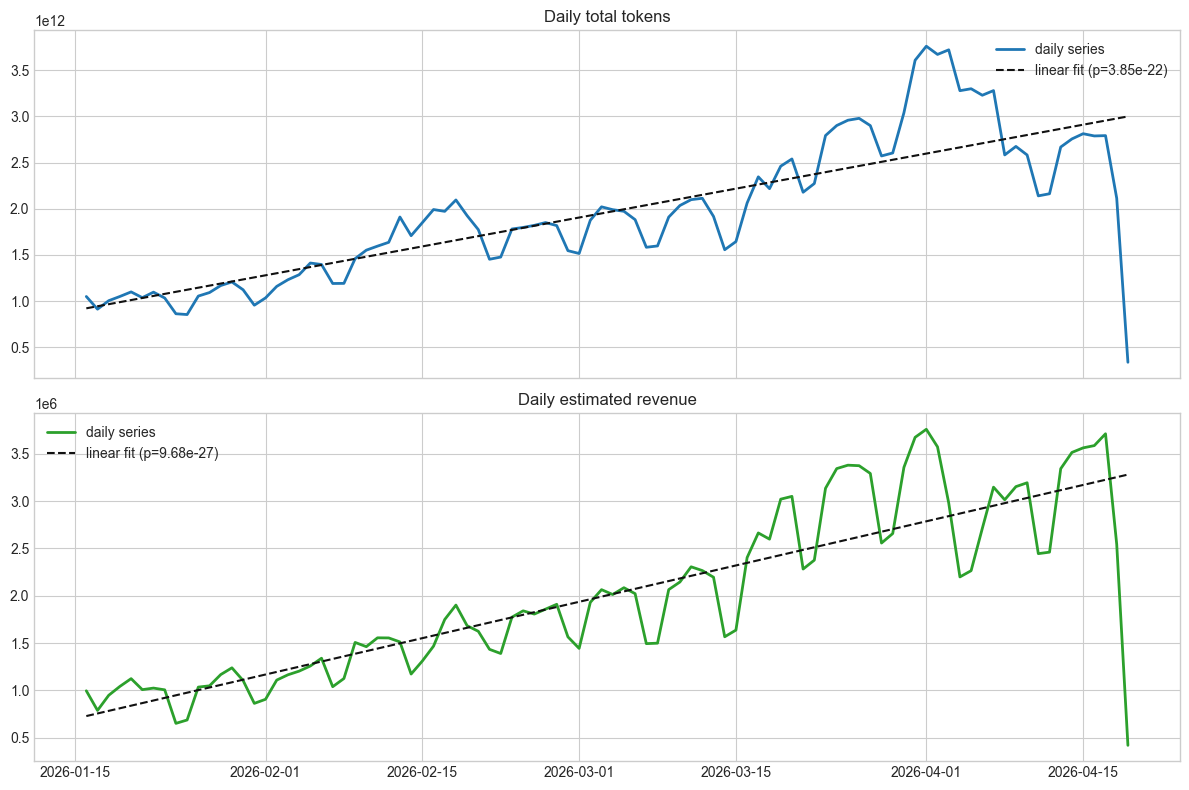

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, column, title, color in [
    (axes[0], 'total_tokens', 'Daily total tokens', '#1f77b4'),
    (axes[1], 'estimated_revenue', 'Daily estimated revenue', '#2ca02c'),
]:
    slope, intercept, r_value, p_value, _ = stats.linregress(daily['t'], daily[column])
    ax.plot(daily['usage_date'], daily[column], color=color, linewidth=2, label='daily series')
    ax.plot(
        daily['usage_date'],
        intercept + slope * daily['t'],
        color='#111111',
        linestyle='--',
        linewidth=1.5,
        label=f'linear fit (p={p_value:.2e})',
    )
    ax.set_title(title)
    ax.legend()

plt.tight_layout()


## Statistical checks

The helper below estimates:
- linear trend slope and p-value
- raw lag-7 autocorrelation
- lag-7 autocorrelation after removing the linear trend
- detrended weekday residual means and ANOVA p-value


In [4]:
def analyze_series(frame: pd.DataFrame, column: str) -> tuple[dict[str, float], pd.DataFrame]:
    y = frame[column].astype(float).to_numpy()
    t = frame['t'].astype(float).to_numpy()
    slope, intercept, r_value, p_value, slope_stderr = stats.linregress(t, y)
    fitted = intercept + slope * t
    resid = y - fitted

    enriched = frame[['usage_date', 'weekday']].copy()
    enriched[column] = y
    enriched['fitted'] = fitted
    enriched['resid'] = resid

    weekday_resid = (
        enriched.groupby('weekday', as_index=False)
        .agg(mean_residual=('resid', 'mean'))
    )
    weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekday_resid['weekday'] = pd.Categorical(weekday_resid['weekday'], categories=weekday_order, ordered=True)
    weekday_resid = weekday_resid.sort_values('weekday').reset_index(drop=True)

    groups = [enriched.loc[enriched['weekday'] == day, 'resid'].to_numpy() for day in weekday_order]
    anova_f, anova_p = stats.f_oneway(*groups)

    summary = {
        'series': column,
        'start_date': enriched['usage_date'].min().strftime('%Y-%m-%d'),
        'end_date': enriched['usage_date'].max().strftime('%Y-%m-%d'),
        'observations': int(len(enriched)),
        'mean_level': float(np.mean(y)),
        'linear_slope_per_day': float(slope),
        'trend_r': float(r_value),
        'trend_p_value': float(p_value),
        'lag_1_autocorr': float(pd.Series(y).autocorr(lag=1)),
        'lag_7_autocorr': float(pd.Series(y).autocorr(lag=7)),
        'lag_7_autocorr_detrended': float(pd.Series(resid).autocorr(lag=7)),
        'weekday_anova_p_value_detrended': float(anova_p),
        'weekday_anova_f_stat_detrended': float(anova_f),
    }
    return summary, weekday_resid

summaries = []
weekday_tables = {}
for metric in ['total_tokens', 'estimated_revenue']:
    summary, weekday_table = analyze_series(daily, metric)
    summaries.append(summary)
    weekday_tables[metric] = weekday_table

summary_df = pd.DataFrame(summaries)
summary_df


,series,start_date,end_date,observations,mean_level,linear_slope_per_day,trend_r,trend_p_value,lag_1_autocorr,lag_7_autocorr,lag_7_autocorr_detrended,weekday_anova_p_value_detrended,weekday_anova_f_stat_detrended
0,total_tokens,2026-01-16,2026-04-19,94,"1,961,021,127,677.234","22,347,993,488.292",0.800,0.000,0.928,0.798,0.383,0.005,3.405
1,estimated_revenue,2026-01-16,2026-04-19,94,"2,004,260.916","27,454.908",0.845,0.000,0.897,0.902,0.644,0.000,10.216


In [5]:
weekday_tables['total_tokens']


,weekday,mean_residual
0,Monday,"78,376,748,168.357"
1,Tuesday,"180,585,511,261.835"
2,Wednesday,"137,540,783,524.774"
3,Thursday,"143,436,633,050.021"
4,Friday,"92,908,694,125.414"
5,Saturday,"-242,899,565,307.806"
6,Sunday,"-351,381,685,107.954"


In [6]:
weekday_tables['estimated_revenue']


,weekday,mean_residual
0,Monday,"104,139.187"
1,Tuesday,"235,516.249"
2,Wednesday,"233,697.913"
3,Thursday,"237,134.136"
4,Friday,"161,362.383"
5,Saturday,"-390,506.091"
6,Sunday,"-523,451.813"


## Detrended weekday pattern

Positive residuals mean that day tends to sit above the linear trend. Negative residuals mean the day tends to sit below trend.


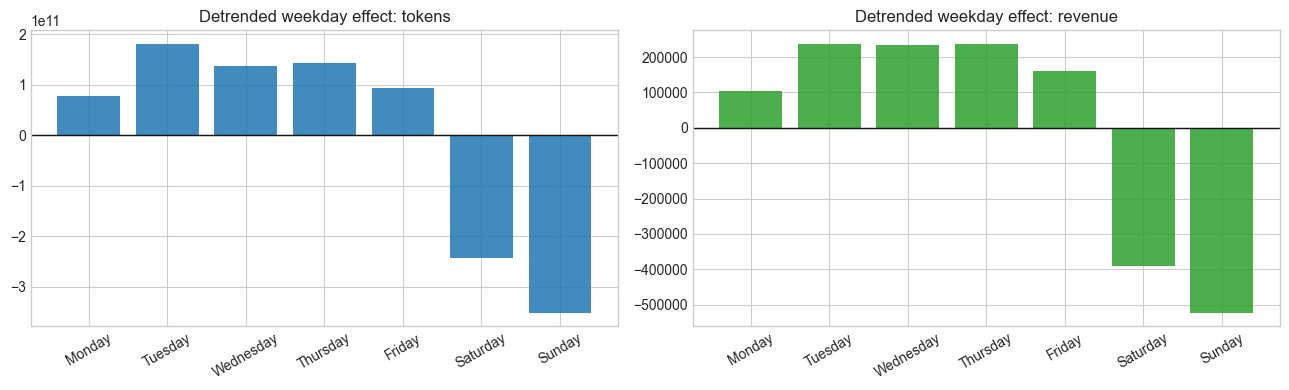

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, metric, title, color in [
    (axes[0], 'total_tokens', 'Detrended weekday effect: tokens', '#1f77b4'),
    (axes[1], 'estimated_revenue', 'Detrended weekday effect: revenue', '#2ca02c'),
]:
    plot_df = weekday_tables[metric]
    ax.bar(plot_df['weekday'].astype(str), plot_df['mean_residual'], color=color, alpha=0.85)
    ax.axhline(0, color='#111111', linewidth=1)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()


## Takeaway

What this notebook should show on the current snapshot:
- Both daily tokens and daily revenue have a strong positive linear trend over the January 16, 2026 to April 19, 2026 window.
- Both also show a weekly structure, with Tuesday to Thursday above trend and Saturday/Sunday below trend.
- Revenue exhibits the clearest weekly seasonality after detrending, but tokens also retain a meaningful lag-7 signature.

This is a good setup for the next modeling pass:
- start with a linear trend + weekday dummies baseline
- then compare against STL + ARIMA/SARIMA on residuals
- optionally model `log1p(total_tokens)` and `log1p(estimated_revenue)` if variance growth becomes an issue
